<a href="https://colab.research.google.com/github/the-menna-sherif/fintech-prep/blob/main/fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Projects

This notebook will contain my projects to retrain and perfect my base coding skills. It will mostly target fintech related datasets and tasks, for obvious reasons :🇩

## First project: Fraud Detection
### Dataset:
https://www.kaggle.com/code/carlmcbrideellis/classification-how-imbalanced-is-imbalanced


In [ ]:
# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("/content/AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
df.shape # rows,columns

(56203, 11)

## Data Inspection

From the below, we can see our target is the isFraud column. The isFlaggedFraud column will help determine the confusion matrix. There are 10 cols and the target (float64).
Note: Good practice would be to change it to boolean.

### Data breakdown
To successfully plan and execute an ML pipeline, we must have clean and well understood data. Steps:

1) Class balance: 0.083114% isFraud 0, 99.916886% isFraud 1 (highly imbalanced)

2) Null count:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56203 entries, 0 to 56202
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            56203 non-null  int64  
 1   type            56203 non-null  object 
 2   amount          56202 non-null  float64
 3   nameOrig        56202 non-null  object 
 4   oldbalanceOrg   56202 non-null  float64
 5   newbalanceOrig  56202 non-null  float64
 6   nameDest        56202 non-null  object 
 7   oldbalanceDest  56202 non-null  float64
 8   newbalanceDest  56202 non-null  float64
 9   isFraud         56202 non-null  float64
 10  isFlaggedFraud  56202 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 4.7+ MB


## Data (Im)balance

As the below table shows, our dataset is highly imbalanced! The actual nonfraudulent transactions amount to less that 0.01%! This will present difficulty during our model training (overfitting, etc.).
For isFlaggedFraud, it is even more imbalanced with 2 fraudulent transactions!

In [ ]:
# isFraud

counts = df["isFraud"].value_counts()
percentages = df["isFraud"].value_counts(normalize=True) * 100

result = pd.DataFrame({
    'count': counts,
    'percentage': percentages
})

print(result)

         count  percentage
isFraud                   
0.0      56102    99.82207
1.0        100     0.17793


In [ ]:
# isFlaggedFraud

counts = df["isFlaggedFraud"].value_counts()
percentages = df["isFlaggedFraud"].value_counts(normalize=True) * 100

result = pd.DataFrame({
    'count': counts,
    'percentage': percentages
})

print(result)

                 count  percentage
isFlaggedFraud                    
0.0             463643       100.0


## Data cleanliness

To avoid falling into pitfalls of the NaNs of Nulls, such as info loss, bias, ML model failure, distorted stats, we take a look at the count.

In [ ]:
# count of nulls per column
print(df.isnull().sum())

# null entries in dataset as a whole (sum of above)
print("Total nulls: ", df.isnull().sum().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64
Total nulls:  3


# Data distribution and general stats

In [ ]:
df["amount"].describe().astype(int)

,amount
count,463644
mean,168799
std,276559
min,0
25%,13466
50%,81913
75%,225648
max,10000000


## Data Visualization


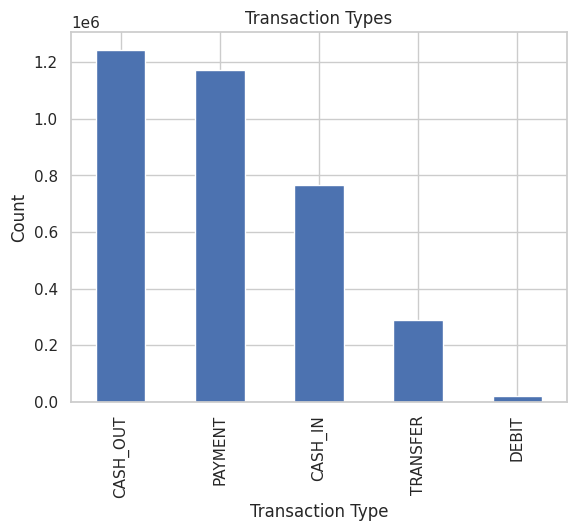

In [ ]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

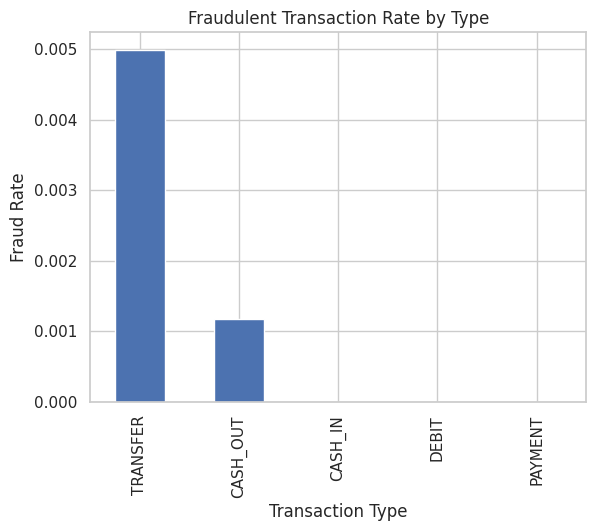

In [ ]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraudulent Transaction Rate by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()


In [ ]:
# quick check if actually zeroes
fraud_by_type

,isFraud
type,
TRANSFER,0.004990
CASH_OUT,0.001174
CASH_IN,0.000000
DEBIT,0.000000
PAYMENT,0.000000


<function matplotlib.pyplot.show(close=None, block=None)>

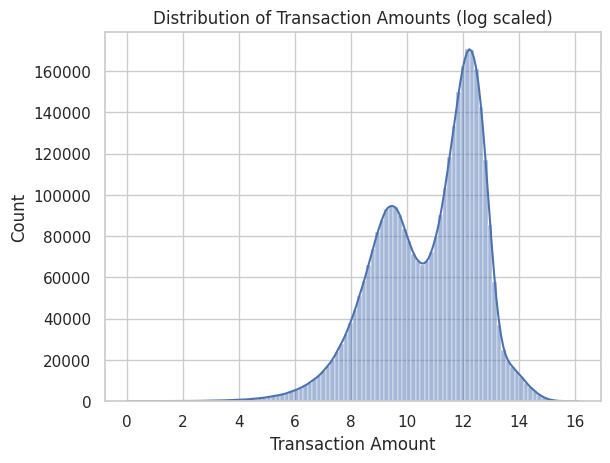

In [ ]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True)
plt.title("Distribution of Transaction Amounts (log scaled)")
plt.xlabel("Transaction Amount")
plt.show

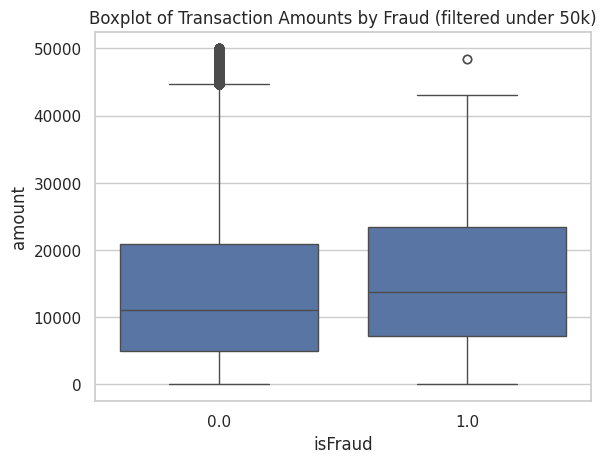

In [ ]:
sns.boxplot(data=df[df['amount']<50000],x="isFraud",y="amount")
plt.title("Boxplot of Transaction Amounts by Fraud (filtered under 50k)")
plt.show()

In [ ]:
df["balanceDiffOrig"] = df['oldbalanceOrg'] - df['newbalanceOrig']
df["balanceDiffDest"] = df['oldbalanceDest'] - df['newbalanceDest']

In [ ]:
# feature showing how much the receiver's balance changed per transaction
(df["balanceDiffDest"] < 0).sum()

np.int64(209529)

In [ ]:
# feature showing how much the sender’s balance changed per transaction
(df["balanceDiffOrig"] < 0).sum()

np.int64(101138)

In [ ]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0


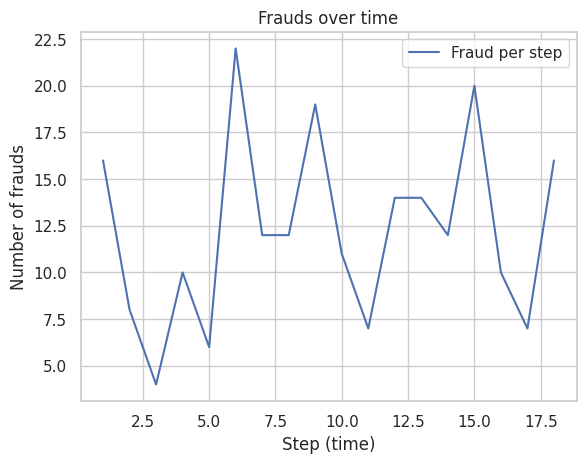

In [ ]:
fraud_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values, label="Fraud per step")
plt.xlabel("Step (time)")
plt.ylabel("Number of frauds")
plt.title("Frauds over time")
plt.legend()
plt.show()

In [ ]:
df.drop(columns='step',inplace=True)

In [ ]:
# customers with most transxns

top_senders = df['nameOrig'].value_counts().head(10)
top_senders # number of transactions is 1 (most)

,count
nameOrig,
C1632500548,1
C1231006815,1
C1666544295,1
C1305486145,1
C840083671,1
C2048537720,1
C90045638,1
C154988899,1
C1912850431,1


In [ ]:
top_receivers = df['nameDest'].value_counts().head(10)
top_receivers  # number of transactions is 75 (most) --> accounts

,count
nameDest,
C985934102,75
C1286084959,68
C1590550415,64
C2083562754,62
C248609774,61
C977993101,61
C665576141,60
C1360767589,60
C1899073220,53


In [ ]:
fraud_users = df[df['isFraud']==1]['nameOrig'].value_counts().head(10)
fraud_users

,count
nameOrig,
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1
C137533655,1
C1118430673,1
C749981943,1
C1334405552,1
C467632528,1


In [ ]:
# fraud_types = df[df['isFraud']==1]['type']
fraud_types = df[df['type'].isin(['CASH_OUT','TRANSFER'])]

fraud_types

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1.0,0.0
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1.0,0.0
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0.0,0.0
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0.0,0.0
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
56193,TRANSFER,49007.02,C3161853,15125.00,0.0,C501402989,1003407.44,708216.56,0.0,0.0
56194,CASH_OUT,413880.91,C1022665684,0.00,0.0,C1694731927,1423559.33,3049415.25,0.0,0.0
56195,TRANSFER,1053427.42,C1219628747,200817.08,0.0,C190097337,0.00,1786573.98,0.0,0.0
56196,TRANSFER,2781310.15,C1490353954,0.00,0.0,C1802632685,5367945.86,9452880.13,0.0,0.0


In [ ]:
fraud_types['type'].value_counts()

,count
type,
CASH_OUT,15672
TRANSFER,5267


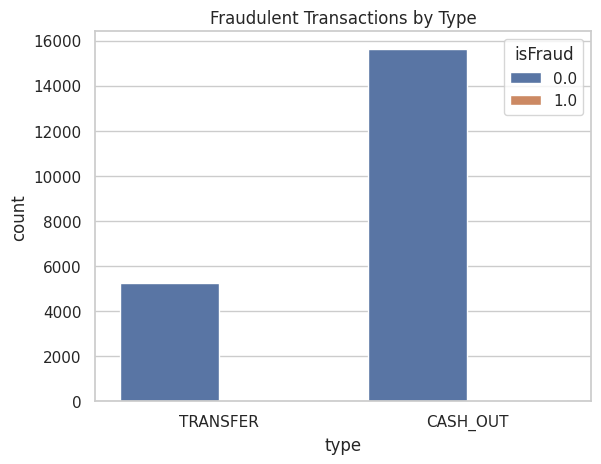

In [ ]:
sns.countplot(data=fraud_types, x='type', hue='isFraud')
plt.title("Fraudulent Transactions by Type")
plt.show()

In [ ]:
corr = df[['amount', 'oldbalanceOrg', "newbalanceOrig",'oldbalanceDest','newbalanceDest','isFraud']].corr()

In [ ]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.003141,-0.006750,0.280046,0.400350,0.053073
oldbalanceOrg,0.003141,1.000000,0.998312,0.118636,0.084772,-0.002842
newbalanceOrig,-0.006750,0.998312,1.000000,0.121091,0.084138,-0.013623
oldbalanceDest,0.280046,0.118636,0.121091,1.000000,0.929135,-0.011274
newbalanceDest,0.400350,0.084772,0.084138,0.929135,1.000000,-0.007438
isFraud,0.053073,-0.002842,-0.013623,-0.011274,-0.007438,1.000000


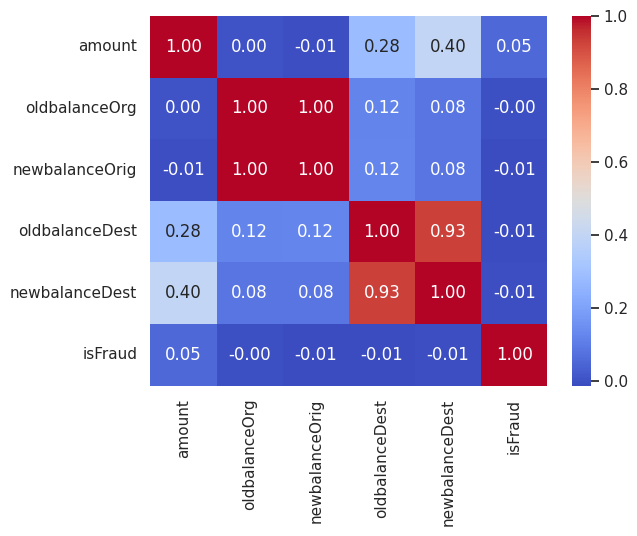

In [ ]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
zero_after_transfer = df[
    (df['newbalanceOrig']==0) &
    (df['oldbalanceOrg']>0) &
    (df['type'].isin(['CASH_OUT', 'TRANSFER']))
]

In [ ]:
zero_after_transfer # suspisious records

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1.0,0.0
3,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1.0,0.0
15,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0.0,0.0
19,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0.0,0.0
24,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
56183,CASH_OUT,120376.05,C1804652434,24733.00,0.0,C1193568854,20202.00,276787.26,0.0,0.0
56185,CASH_OUT,6125.47,C612368215,1049.00,0.0,C1162171909,350526.99,3994004.79,0.0,0.0
56189,CASH_OUT,67905.09,C1870296674,1164.00,0.0,C1777365519,0.00,67905.09,0.0,0.0
56193,TRANSFER,49007.02,C3161853,15125.00,0.0,C501402989,1003407.44,708216.56,0.0,0.0


In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

# Feature Engineering & Pipeline prep

In [ ]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,56102
1.0,100


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df_model = df.drop(['nameOrig', 'nameDest', "isFlaggedFraud"], axis=1)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0


In [ ]:
categorical = ["type"]
numerical = ["amount",	"oldbalanceOrg",	"newbalanceOrig",	"oldbalanceDest",	"newbalanceDest"]

df_model = df_model.dropna(subset=['isFraud']) # added to avoid "ValueError: Input y contains NaN." error
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

### Train Test Split note: **stratify=y**

Ensures similar distribution of classes in train/ test data

IF **OG data** has a 75/25 notFraud/ isFraud split

**train** will have 75/25 notFraud/ isFraud split

**test** will have 75/25 notFraud/ isFraud split

Check:

```
y_train.mean() ~= y_test.mean()
```



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [ ]:
# Stratification check --> PASS

print("Fraud % in train: " , y_train.mean())
print("Fraud % in test: " , y_test.mean())

Fraud % in train:  0.0017793142014692052
Fraud % in test:  0.0017792538995314632


In [ ]:
preprocessor = ColumnTransformer(
    transformers= [
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)


In [ ]:
pipeline_XGBoost = Pipeline([
    ("preprocessor", preprocessor),
    # ("clf", LogisticRegression(class_weight='balanced', max_iter=1000))
    ("clf", XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

In [ ]:
pipeline_Logistic = Pipeline([
    ("preprocessor", preprocessor),
    # ("clf", LogisticRegression(class_weight='balanced', max_iter=1000))
    ("clf", LogisticRegression()),
])

In [ ]:
pipeline_XGBoost.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, dev...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
pipeline_Logistic.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf', LogisticRegression())])

In [ ]:
y_pred_XGBoost = pipeline_XGBoost.predict(X_test)

In [ ]:
y_pred_Logistic = pipeline_Logistic.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_XGBoost))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     16831
         1.0       0.94      0.53      0.68        30

    accuracy                           1.00     16861
   macro avg       0.97      0.77      0.84     16861
weighted avg       1.00      1.00      1.00     16861



In [ ]:
print(classification_report(y_test, y_pred_Logistic))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     16831
         1.0       0.00      0.00      0.00        30

    accuracy                           1.00     16861
   macro avg       0.50      0.50      0.50     16861
weighted avg       1.00      1.00      1.00     16861



In [ ]:
confusion_matrix(y_test, y_pred_XGBoost)

array([[16830,     1],
       [   14,    16]])

In [ ]:
pipeline_XGBoost.score(X_test, y_test) * 100

99.91103730502343

In [ ]:
pipeline_Logistic.score(X_test, y_test) * 100

99.82207461004685